In [1]:
import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("90daysgoal.csv")
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.317991e+09,65,i.imgur.com,l428f,My motivation,koenigta,74,9,7,http://www.reddit.com/r/90daysgoal/comments/l4...,...,False,http://thumbs.reddit.com/t3_l428f.png,t5_2s0sd,False,NaN,silver5,False,t3_l428f,http://i.imgur.com/4aBob.jpg,NaN
1,1.308406e+09,58,i.imgur.com,i2xig,"[MOTIVATION] 4 months in, 44 lbs gone. Progres...",princessbitchtits,59,1,14,http://www.reddit.com/r/90daysgoal/comments/i2...,...,False,http://thumbs.reddit.com/t3_i2xig.png,t5_2s0sd,False,NaN,self4,False,t3_i2xig,http://i.imgur.com/Dep2z.jpg,NaN
2,1.317668e+09,51,imgur.com,kzmcr,Second Week on a Diet,ciretose24,58,7,10,http://www.reddit.com/r/90daysgoal/comments/kz...,...,False,http://thumbs.reddit.com/t3_kzmcr.png,t5_2s0sd,False,NaN,NaN,False,t3_kzmcr,http://imgur.com/gZjR2,NaN
3,1.317020e+09,41,self.90daysgoal,krlrq,"[Dailygoal][To-do] Day 1 - September 26th, 2011",Feckless,50,9,142,http://www.reddit.com/r/90daysgoal/comments/kr...,...,False,self,t5_2s0sd,True,NaN,self1,True,t3_krlrq,http://www.reddit.com/r/90daysgoal/comments/kr...,moderator
4,1.317092e+09,45,i.imgur.com,ksio4,"[INTRO] ""Before"" Pic taken today. I've lost ab...",redheaddit,49,4,11,http://www.reddit.com/r/90daysgoal/comments/ks...,...,False,http://thumbs.reddit.com/t3_ksio4.png,t5_2s0sd,False,NaN,silver2,False,t3_ksio4,http://i.imgur.com/Vcs19.jpg,NaN


In [5]:


df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.317991e+09,65,i.imgur.com,l428f,My motivation,koenigta,74,9,7,http://www.reddit.com/r/90daysgoal/comments/l4...,...,False,http://thumbs.reddit.com/t3_l428f.png,t5_2s0sd,False,NaN,silver5,False,t3_l428f,http://i.imgur.com/4aBob.jpg,NaN
1,1.308406e+09,58,i.imgur.com,i2xig,"[MOTIVATION] 4 months in, 44 lbs gone. Progres...",princessbitchtits,59,1,14,http://www.reddit.com/r/90daysgoal/comments/i2...,...,False,http://thumbs.reddit.com/t3_i2xig.png,t5_2s0sd,False,NaN,self4,False,t3_i2xig,http://i.imgur.com/Dep2z.jpg,NaN
2,1.317668e+09,51,imgur.com,kzmcr,Second Week on a Diet,ciretose24,58,7,10,http://www.reddit.com/r/90daysgoal/comments/kz...,...,False,http://thumbs.reddit.com/t3_kzmcr.png,t5_2s0sd,False,NaN,NaN,False,t3_kzmcr,http://imgur.com/gZjR2,NaN
3,1.317020e+09,41,self.90daysgoal,krlrq,"[Dailygoal][To-do] Day 1 - September 26th, 2011",Feckless,50,9,142,http://www.reddit.com/r/90daysgoal/comments/kr...,...,False,self,t5_2s0sd,True,NaN,self1,True,t3_krlrq,http://www.reddit.com/r/90daysgoal/comments/kr...,moderator
4,1.317092e+09,45,i.imgur.com,ksio4,"[INTRO] ""Before"" Pic taken today. I've lost ab...",redheaddit,49,4,11,http://www.reddit.com/r/90daysgoal/comments/ks...,...,False,http://thumbs.reddit.com/t3_ksio4.png,t5_2s0sd,False,NaN,silver2,False,t3_ksio4,http://i.imgur.com/Vcs19.jpg,NaN


In [7]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [9]:
# Select features (example: using all numeric columns)
X = df.select_dtypes(include=['number'])

# OR manually choose columns
# X = df[['col1', 'col2', 'col3']]

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

In [11]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished', 'Cluster'],
      dtype='str')


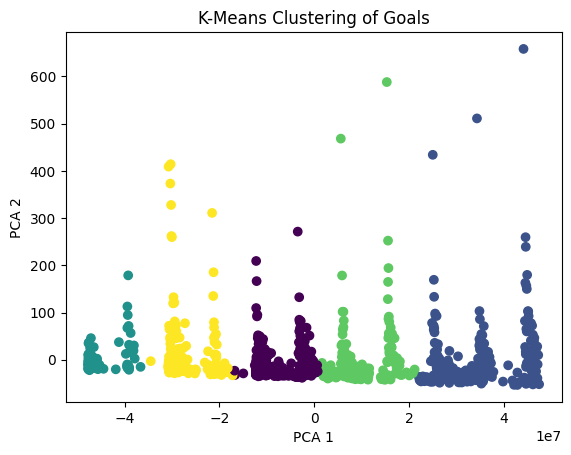

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(X)  # <-- fixed here

plt.scatter(reduced[:,0], reduced[:,1], c=df["Cluster"])
plt.title("K-Means Clustering of Goals")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()